In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
df=pd.read_csv('/content/transactions.csv')

In [62]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [63]:
df.sample(10)

,order_id,user_id,product_id,price,quantity,timestamp,channel
47167,ORD016799,U03943,P138,9.51,2,2025-12-10 15:07:04.822715,Website
37442,ORD046421,U04543,P011,17.43,1,2025-10-29 13:07:04.822715,Website
41795,ORD049858,U03928,P123,7.69,3,2026-04-02 07:07:04.822715,Retail
4880,ORD012962,U02698,P102,25.44,1,2026-04-09 18:07:04.822715,Gym Kiosk
11883,ORD042264,U04351,P029,79.50,1,2026-02-13 11:07:04.822715,Marketplace
23895,ORD033681,U01805,P093,17.12,2,2025-07-05 12:07:04.822715,Gym Kiosk
20434,ORD008192,U03147,P071,14.47,1,2025-05-02 23:07:04.822715,Marketplace
2751,ORD023629,U01193,P046,14.07,2,2025-08-26 10:07:04.822715,App
38750,ORD047541,U02523,P107,9.51,2,2025-10-02 18:07:04.822715,Retail
44533,ORD011753,U01198,P040,7.72,2,2026-01-23 10:07:04.822715,Retail


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50150 entries, 0 to 50149
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    50150 non-null  object 
 1   user_id     50150 non-null  object 
 2   product_id  50150 non-null  object 
 3   price       50150 non-null  float64
 4   quantity    50150 non-null  int64  
 5   timestamp   50150 non-null  object 
 6   channel     50150 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 2.7+ MB


In [65]:
df.describe()

,price,quantity
count,50150.000000,50150.000000
mean,57.013641,4.004088
std,411.863741,20.370840
min,-210.160000,-6.000000
25%,10.370000,1.000000
50%,16.800000,2.000000
75%,35.240000,3.000000
max,18641.000000,299.000000


##No missing Data

In [66]:
df.duplicated().sum()

np.int64(150)

In [67]:
df.drop_duplicates(inplace=True)

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
df['channel'].value_counts()

,count
channel,
Website,10060
App,10034
Gym Kiosk,10005
Marketplace,9961
Retail,9940


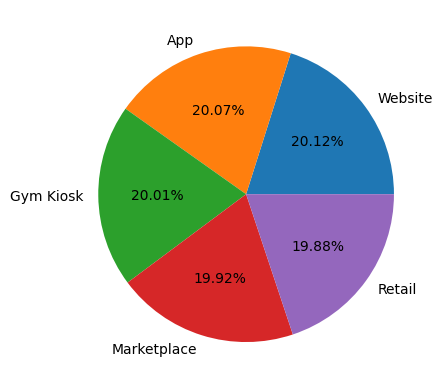

In [70]:
plt.pie(df['channel'].value_counts(),labels=df['channel'].value_counts().index,autopct='%1.2f%%')
plt.show()

##Almost similar distribution of channels

In [71]:
df[(df['price'] <= 0) & (df['quantity'] <= 0)].shape

(1063, 7)

In [72]:
df[(df['price'] <= 0) & (df['quantity'] <= 0)].sample(20)

,order_id,user_id,product_id,price,quantity,timestamp,channel
4440,ORD029159,U02729,P121,-61.33,-3,2025-11-24 05:07:04.822715,Retail
9721,ORD014846,U04518,P148,-23.54,-2,2025-08-11 07:07:04.822715,Gym Kiosk
7492,ORD045390,U04173,P119,-10.30,-1,2025-08-22 10:07:04.822715,Marketplace
10490,ORD014545,U00373,P143,-12.72,-1,2025-04-28 09:07:04.822715,Gym Kiosk
27313,ORD044649,U00077,P080,-14.54,-2,2025-08-10 08:07:04.822715,Retail
45274,ORD045841,U02165,P127,-126.59,-2,2025-05-30 17:07:04.822715,Website
29764,ORD015630,U02419,P145,-6.03,-2,2025-09-07 16:07:04.822715,Marketplace
21047,ORD006018,U00490,P121,-52.15,-3,2025-08-19 09:07:04.822715,App
4452,ORD022274,U04059,P074,-22.15,-1,2025-09-08 18:07:04.822715,Marketplace
48364,ORD035618,U00460,P043,-21.39,-2,2025-08-12 22:07:04.822715,App


In [73]:
df[df['product_id']=='P119']

,order_id,user_id,product_id,price,quantity,timestamp,channel
313,ORD041026,U02901,P119,1030.00,3,2026-03-24 08:07:04.822715,Website
363,ORD013325,U03580,P119,10.30,2,2026-03-12 06:07:04.822715,Gym Kiosk
396,ORD027430,U02829,P119,10.30,3,2026-02-16 07:07:04.822715,Gym Kiosk
434,ORD005113,U01843,P119,10.30,2,2025-06-23 13:07:04.822715,Gym Kiosk
484,ORD030073,U01581,P119,10.30,2,2026-01-03 18:07:04.822715,Retail
494,ORD022221,U02794,P119,10.30,3,2026-02-06 18:07:04.822715,Marketplace
575,ORD001229,U02080,P119,10.30,3,2026-03-15 13:07:04.822715,Gym Kiosk
724,ORD040511,U02596,P119,10.30,1,2025-08-09 12:07:04.822715,Retail
829,ORD028704,U04877,P119,12.64,1,2025-06-24 19:07:04.822715,App
1054,ORD033607,U01990,P119,10.30,2,2025-09-27 06:07:04.822715,Gym Kiosk


##In everywhere same product_id has same price in almost same places ,where -ve sign occurs that will be +ve as if we do this then it matches exactly the data prices which have same product_id

In [74]:
def neg(x):
  if(x<0):
    return x*(-1)
  else:
    return x
df['price']=df['price'].apply(neg)
df['quantity']=df['quantity'].apply(neg)

In [75]:
df.describe()

,price,quantity
count,50000.000000,50000.000000
mean,58.154038,4.099600
std,407.222003,20.383141
min,0.000000,1.000000
25%,10.657500,1.000000
50%,17.230000,2.000000
75%,36.870000,3.000000
max,18641.000000,299.000000


In [76]:
df[df['price']==0].shape

(249, 7)

In [77]:
df[df['quantity']==0].shape

(0, 7)

In [78]:
df[df['price']==0].sample(10)

,order_id,user_id,product_id,price,quantity,timestamp,channel
16467,ORD002681,U01659,P048,0.0,1,2025-07-25 09:07:04.822715,Retail
45953,ORD038894,U03485,P047,0.0,1,2025-06-27 02:07:04.822715,Gym Kiosk
31421,ORD041152,U04320,P056,0.0,3,2025-10-10 13:07:04.822715,Marketplace
4788,ORD000017,U01116,P050,0.0,2,2025-10-23 12:07:04.822715,App
48088,ORD049274,U01188,P057,0.0,6,2025-06-27 01:07:04.822715,Website
24904,ORD030637,U00484,P040,0.0,2,2026-04-06 04:07:04.822715,Retail
16582,ORD015341,U00319,P006,0.0,2,2025-09-07 00:07:04.822715,Gym Kiosk
23695,ORD039227,U04818,P126,0.0,3,2025-12-21 16:07:04.822715,Website
30081,ORD048916,U01385,P121,0.0,2,2026-03-31 11:07:04.822715,Gym Kiosk
18925,ORD027232,U02248,P131,0.0,2,2026-03-19 05:07:04.822715,App


In [79]:
#Check with different product_id is it 0 or some data entry error
df[df['product_id']=='P134'].describe()

,price,quantity
count,344.000000,344.000000
mean,32.242616,3.494186
std,162.842757,19.138287
min,0.000000,1.000000
25%,18.210000,1.000000
50%,18.210000,2.000000
75%,22.552500,3.000000
max,2449.000000,275.000000


In [80]:
#I found there is some data entry error
df['price']=df['price'].replace(0,np.nan)

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 50149
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    50000 non-null  object 
 1   user_id     50000 non-null  object 
 2   product_id  50000 non-null  object 
 3   price       49751 non-null  float64
 4   quantity    50000 non-null  int64  
 5   timestamp   50000 non-null  object 
 6   channel     50000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 3.1+ MB


<Axes: xlabel='price', ylabel='Count'>

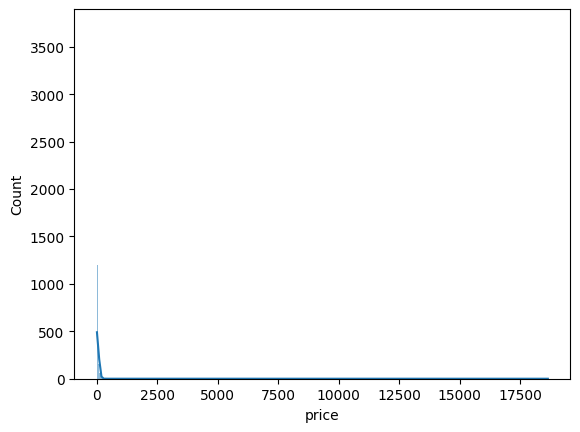

In [82]:
sns.histplot(df['price'], kde=True)

In [83]:
df['price'].describe(percentiles=[.01, .05, .25, .50, .75, .90, .95, .99])

,price
count,49751.000000
mean,58.445095
std,408.218974
min,2.810000
1%,5.130000
5%,6.795000
25%,10.690000
50%,17.320000
75%,36.960000
90%,76.300000


In [84]:
df[df['price']>=227].shape

(497, 7)

In [85]:
df[df['price']>=227]['product_id'].value_counts().head(5)

,count
product_id,
P097,9
P031,9
P146,8
P075,8
P085,7


#Manually check those product id those price section have much bigger values

In [86]:
df[df['product_id']=='P075'].sample(20)

,order_id,user_id,product_id,price,quantity,timestamp,channel
44722,ORD012418,U00075,P075,54.23,3,2025-04-29 23:07:04.822715,Retail
15235,ORD048168,U02647,P075,46.15,1,2025-05-17 01:07:04.822715,App
32339,ORD002986,U00959,P075,50.87,3,2026-01-07 01:07:04.822715,Website
49509,ORD006764,U00945,P075,41.21,1,2025-06-05 21:07:04.822715,App
22518,ORD028095,U00194,P075,60.79,2,2025-05-05 16:07:04.822715,App
9648,ORD018198,U02347,P075,34.83,6,2025-11-12 02:07:04.822715,Marketplace
20929,ORD014059,U03115,P075,74.40,1,2026-04-03 05:07:04.822715,Marketplace
14048,ORD021256,U03321,P075,59.64,236,2026-03-02 14:07:04.822715,Retail
67,ORD042824,U03265,P075,56.69,1,2025-07-15 18:07:04.822715,Retail
30797,ORD004240,U00719,P075,57.72,1,2025-05-23 04:07:04.822715,App


##Their is many Extreme Values in this price column.

In [87]:
df[df['price'].isnull()].sample(10)

,order_id,user_id,product_id,price,quantity,timestamp,channel
4139,ORD043579,U03359,P008,NaN,2,2025-05-27 23:07:04.822715,Marketplace
32422,ORD016206,U04284,P012,NaN,4,2025-10-31 19:07:04.822715,Gym Kiosk
42813,ORD048351,U00859,P125,NaN,5,2026-01-21 18:07:04.822715,Gym Kiosk
6411,ORD005046,U02877,P062,NaN,3,2026-01-21 23:07:04.822715,Retail
35468,ORD047474,U04570,P137,NaN,1,2025-04-26 22:07:04.822715,Gym Kiosk
33368,ORD018212,U02156,P144,NaN,2,2026-01-24 01:07:04.822715,Gym Kiosk
13791,ORD042807,U00053,P016,NaN,3,2026-01-25 19:07:04.822715,App
24229,ORD025889,U04187,P029,NaN,3,2025-09-03 16:07:04.822715,Retail
3432,ORD005253,U00560,P099,NaN,1,2025-11-19 13:07:04.822715,Retail
43706,ORD006536,U02726,P073,NaN,2,2025-07-28 13:07:04.822715,Gym Kiosk


In [88]:
# Most frequent price for each product_id
product_price_mode = (
    df.groupby('product_id')['price']
      .transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)
# Impute NaN prices using product-wise most frequent price
df['price'] = df['price'].fillna(product_price_mode)

In [89]:
df[df['price'].isnull()]

,order_id,user_id,product_id,price,quantity,timestamp,channel


In [90]:
df['price'].describe(percentiles=[.01, .05, .25, .50, .75, .90, .95, .99])

,price
count,50000.000000
mean,58.294224
std,407.212400
min,2.810000
1%,5.130000
5%,6.790000
25%,10.690000
50%,17.300000
75%,36.960000
90%,76.300000


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 50149
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    50000 non-null  object 
 1   user_id     50000 non-null  object 
 2   product_id  50000 non-null  object 
 3   price       50000 non-null  float64
 4   quantity    50000 non-null  int64  
 5   timestamp   50000 non-null  object 
 6   channel     50000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 3.1+ MB


In [92]:
df['quantity'].describe()

,quantity
count,50000.000000
mean,4.099600
std,20.383141
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,299.000000


In [93]:
df['quantity'].describe(percentiles=[.01, .05, .25, .50, .75, .90, .95, .99])

,quantity
count,50000.000000
mean,4.099600
std,20.383141
min,1.000000
1%,1.000000
5%,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
90%,3.000000


In [94]:
df[df['quantity']>103].shape

(496, 7)

In [95]:
df[df['quantity']>103].sample(10)

,order_id,user_id,product_id,price,quantity,timestamp,channel
8205,ORD010947,U04175,P108,104.99,217,2026-03-17 01:07:04.822715,App
33255,ORD010617,U00491,P061,34.75,233,2025-07-05 09:07:04.822715,App
16229,ORD012894,U00182,P097,17.71,237,2025-06-30 19:07:04.822715,Retail
6754,ORD036757,U02091,P137,5.24,168,2025-05-04 12:07:04.822715,Website
25322,ORD018404,U01924,P039,43.55,115,2025-06-04 10:07:04.822715,Retail
45076,ORD025123,U03902,P097,14.72,106,2025-12-05 19:07:04.822715,Marketplace
24495,ORD036959,U00621,P150,16.60,211,2026-04-08 06:07:04.822715,Gym Kiosk
12182,ORD027062,U04184,P052,12.06,104,2025-12-02 21:07:04.822715,Gym Kiosk
49247,ORD005067,U04198,P014,25.88,129,2026-01-10 01:07:04.822715,Marketplace
30338,ORD047006,U04015,P032,9.04,211,2025-11-24 23:07:04.822715,App


##in price and quantity column we could't understand is these orders are really happens or data error ,so we keep them as it is

In [96]:
df['date']=df['timestamp'].dt.date
df['time']=df['timestamp'].dt.strftime('%H:%M:%S')

AttributeError: Can only use .dt accessor with datetimelike values

In [97]:
df['timestamp']=pd.to_datetime(df['timestamp'])

In [98]:
df['date']=df['timestamp'].dt.date
df['time']=df['timestamp'].dt.strftime('%H:%M:%S')

In [99]:
#drop timestamp column as we create time and date column
df.drop(columns=['timestamp'],inplace=True)

In [100]:
df.sample(10)

,order_id,user_id,product_id,price,quantity,channel,date,time
46638,ORD031582,U04750,P036,24.75,2,Gym Kiosk,2025-12-30,00:07:04
28084,ORD046739,U01952,P128,13.11,2,Website,2025-06-20,13:07:04
63,ORD024219,U03367,P029,79.50,2,Marketplace,2026-02-27,19:07:04
49971,ORD021238,U03318,P146,8.67,2,Gym Kiosk,2025-12-12,06:07:04
18306,ORD004102,U03738,P024,13.55,2,Retail,2026-04-21,14:07:04
34335,ORD038928,U02159,P026,25.03,3,Retail,2025-08-20,07:07:04
30602,ORD032710,U04876,P030,7.14,1,App,2026-03-15,17:07:04
7367,ORD024963,U01496,P148,22.65,2,Marketplace,2025-06-26,08:07:04
13645,ORD033842,U01256,P013,16.49,2,Retail,2025-10-01,14:07:04
16277,ORD000528,U04353,P150,12.52,2,Gym Kiosk,2026-03-30,22:07:04


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 50149
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    50000 non-null  object 
 1   user_id     50000 non-null  object 
 2   product_id  50000 non-null  object 
 3   price       50000 non-null  float64
 4   quantity    50000 non-null  int64  
 5   channel     50000 non-null  object 
 6   date        50000 non-null  object 
 7   time        50000 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 3.4+ MB


In [102]:
from google.colab import files
df.to_csv('cleaned_transactions1.csv', index=False)
files.download('cleaned_transactions1.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>